### 1. IMPORTACIÓN DE LIBRERIAS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from keras.layers import Dense, Dropout, LSTM, TimeDistributed, RepeatVector 
from keras.models import Sequential, load_model  
from keras import regularizers
from joblib import dump, load
from datetime import datetime, timedelta
from pytz import timezone
import shap
import requests

### CONEXION HISTORIADOR CANARY

In [2]:
# # Crear una instancia de CanaryView conectada a 192.168.10.211 con los puertos por defecto
# canary_view = CanaryView(httpPort='55235', httpsPort='55236', host='192.168.10.211')

In [2]:
# URL base del servidor y endpoint de la API
base_url = 'http://192.168.10.211:55235/api'
endpoint = base_url + '/v2/GetTagData2'

In [3]:
# Lista de etiquetas a consultar
tags = ['PEAAAUCOI211.Extraccion_data.Extraccion.molino.UH.I ValueY',
        'PEAAAUCOI211.Extraccion_data.Extraccion.molino.UH.PT ValueY',
        'PEAAAUCOI211.Extraccion_data.Extraccion.molino.masa.TT_MasaCanLL ValueY',
        'PEAAAUCOI211.Extraccion_data.Extraccion.molino.masa.TT_MasaCanLM ValueY',
        'PEAAAUCOI211.Extraccion_data.Extraccion.molino.masa.TT_MasaSupLL ValueY',
        'PEAAAUCOI211.Extraccion_data.Extraccion.molino.masa.TT_MasaSupLM ValueY',
        'PEAAAUCOI211.Extraccion_data.Extraccion.molino.motor.I ValueY',
        'PEAAAUCOI211.Extraccion_data.Extraccion.molino.motor.ST ValueY',
        'PEAAAUCOI211.Extraccion_data.Extraccion.molino.motor.TT_DE ValueY',
        'PEAAAUCOI211.Extraccion_data.Extraccion.molino.motor.TT_NDE ValueY',
        'PEAAAUCOI211.Extraccion_data.Extraccion.molino.motor.TT_R ValueY',
        'PEAAAUCOI211.Extraccion_data.Extraccion.molino.motor.TT_S ValueY',
        'PEAAAUCOI211.Extraccion_data.Extraccion.molino.motor.TT_T ValueY',
        'PEAAAUCOI211.Extraccion_data.Extraccion.molino.motor.VT_DE ValueY',
        'PEAAAUCOI211.Extraccion_data.Extraccion.molino.motor.VT_MotorNDE ValueY',
        'PEAAAUCOI211.Extraccion_data.Extraccion.molino.reductor.VT_I ValueY',
        'PEAAAUCOI211.Extraccion_data.Extraccion.molino.reductor.VT_rII ValueY',
        'PEAAAUCOI211.Calc.Extraccion.molino.motor.Molino_Apagado']

columnas = [
 'UH/I',
 'UH/PT',
 'masa/TT_MasaCanLL',
 'masa/TT_MasaCanLM',
 'masa/TT_MasaSupLL',
 'masa/TT_MasaSupLM',
 'motor/I',
 'motor/ST',
 'motor/TT_DE',
 'motor/TT_NDE',
 'motor/TT_R',
 'motor/TT_S',
 'motor/TT_T',
 'motor/VT_DE',
 'motor/VT_MotorNDE',
 'reductor/VT_I',
 'reductor/VT_rII',
 'Molino Apagado']

### 2. PULL DE DATOS

In [4]:
# Cuerpo de la solicitud
myobj = {
    "userToken": "",
    "tags": tags,
    "startTime": "now-1d",
    "endTime": "now",
    "aggregateName": "TimeAverage",
    "aggregateInterval": "00:00:30"
}

# Realizar la solicitud POST
response = requests.post(url=endpoint, json=myobj)

# Verificar que la solicitud fue exitosa
if response.status_code == 200:
    # Convertir la respuesta JSON
    data = response.json()
    
    # Crear un diccionario para almacenar los datos de cada tag
    tag_dfs = {}

    # Iterar sobre cada tag en la respuesta
    for tag in tags:
        if tag in data['data']:
            tag_data = data['data'][tag]
            
            # Extraer timestamps y valores para el tag actual
            timestamps = [item['t'] for item in tag_data]
            values = [item['v'] for item in tag_data]
            
            # Crear un DataFrame temporal para el tag actual
            tag_df = pd.DataFrame({tag: values}, index=pd.to_datetime(timestamps))
            
            # Agregar el DataFrame temporal al diccionario
            tag_dfs[tag] = tag_df

    # Combinar todos los DataFrames en uno solo, usando el índice de tiempo
    combined_df = pd.concat(tag_dfs.values(), axis=1)

    # Mostrar el DataFrame combinado
    #print(combined_df)
else:
    print("Error en la solicitud:", response.status_code)
    print(response.text)
data = combined_df
data.columns = columnas
data.index = pd.to_datetime(data.index,format='ISO8601').tz_convert('America/Lima')
print(data.shape)
data.describe()

(2880, 18)


,UH/I,masa/TT_MasaCanLL,masa/TT_MasaSupLL,motor/I,motor/ST,motor/TT_DE,motor/TT_NDE,motor/TT_R,motor/TT_S,motor/TT_T,motor/VT_DE,motor/VT_MotorNDE,reductor/VT_I,reductor/VT_rII,Molino Apagado
count,2880.0,2880.000000,2880.000000,2880.000000,2880.0,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.0
mean,0.0,33.630198,33.128011,287.516246,0.0,34.321371,35.103456,40.268980,41.507439,41.694137,0.003704,0.005087,0.007483,0.027410,1.0
std,0.0,7.514158,6.719888,0.024350,0.0,2.362569,4.625829,2.212181,1.370927,1.213644,0.000000,0.001771,0.000614,0.003058,0.0
min,0.0,25.745502,26.785002,287.432624,0.0,31.539351,29.813029,37.671682,39.176313,39.400077,0.003704,0.003704,0.007037,0.015679,1.0
25%,0.0,27.520002,27.520002,287.500484,0.0,32.409335,30.712913,38.420139,40.279708,40.581462,0.003704,0.003704,0.007407,0.025968,1.0
50%,0.0,30.250002,30.559752,287.516530,0.0,33.393206,33.228272,39.611304,41.333839,41.599150,0.003704,0.003704,0.007407,0.029398,1.0
75%,0.0,39.012423,36.478580,287.532574,0.0,36.323783,38.886960,41.610724,42.133860,42.239956,0.003704,0.007407,0.007407,0.029398,1.0
max,0.0,53.836243,59.422767,287.611971,0.0,39.236111,43.456790,45.258485,44.629628,44.444443,0.003704,0.007407,0.022456,0.036748,1.0


In [6]:
data.to_csv('ingreso.csv')

In [7]:
# # Obtener datos historicos para las etiquetas especificadas con restricciones especificas
# days = 0.25
# end = datetime.now(timezone('America/Lima'))
# start = end - timedelta(days=days)

# data_ = canary_view.getTagData(
#     tags=tags,
#     startTime= start,
#     endTime=end,
#     aggregateName='TimeAverage2',
#     aggregateInterval='1min'
# )
# # Convertir el generador a una lista
# data_list = list(data_)

# # Procesar los datos para convertirlos a un DataFrame
# datos = []
# for tag_path, values in data_list:
#     for value in values:
#         datos.append({
#             'etiqueta': tag_path,
#             'timestamp': value['timestamp'],
#             'value': value['value']
#         })

# data = pd.DataFrame(datos)
# data = data.pivot_table(index='timestamp', columns='etiqueta', values='value')
# data.columns = columnas
# print(data.shape)
# data.describe()
# #df_2023.to_csv('data/molino/df_molino_2023.csv',index=True)
# #df_2023 = pd.read_csv('data/molino/df_molino_2023.csv',index_col=0)
# #df_2023.index = pd.to_datetime(df_2023.index,format='ISO8601').tz_convert('America/Lima')

In [8]:
def moving_average_filter(data, columns, window_size):
    filtered_data = data.copy()
    for column in columns:
        filtered_data[column] = data[column].rolling(window=window_size,min_periods=1).mean()
    return filtered_data

In [9]:
# Filtrado de señales

window_size = 20
resample_size = '4S'
df_filt = data.copy()

# Convertir elementos de tipo Arrow a datetime
df_filt.index = df_filt.index.map(lambda x: x.datetime if hasattr(x, 'datetime') else x)

# Convertir el índice a DatetimeIndex
df_filt.index = pd.to_datetime(df_filt.index)
colum_filt = ['UH/I',
              'UH/PT',
              'masa/TT_MasaCanLL',
              'masa/TT_MasaCanLM',
              'masa/TT_MasaSupLL',
              'masa/TT_MasaSupLM',
              'motor/I',
              'motor/ST',
              'motor/TT_DE',
              'motor/TT_NDE',
              'motor/TT_R',
              'motor/TT_S',
              'motor/TT_T']

df_filt = moving_average_filter(df_filt,colum_filt,window_size)
df_filt['Molino Apagado'] = df_filt['Molino Apagado'].rolling('7min',center=True).max()
df_filt['Molino Apagado'] = df_filt['Molino Apagado'].rolling('7min',center=True).max()


In [10]:
df_filt

,UH/I,UH/PT,masa/TT_MasaCanLL,masa/TT_MasaCanLM,masa/TT_MasaSupLL,masa/TT_MasaSupLM,motor/I,motor/ST,motor/TT_DE,motor/TT_NDE,motor/TT_R,motor/TT_S,motor/TT_T,motor/VT_DE,motor/VT_MotorNDE,reductor/VT_I,reductor/VT_rII,Molino Apagado
2025-01-14 08:19:55.224353300-05:00,3.952000,1.753984,68.619725,41.813218,36.774967,38.860004,642.222226,905.200312,48.628039,58.789544,86.594860,89.208670,89.946520,0.733833,0.685586,4.648473,2.951357,0.0
2025-01-14 08:20:25.224353300-05:00,3.952167,1.754529,68.597369,41.807485,36.769234,38.852612,637.671213,951.376567,48.612341,58.791473,86.588807,89.185040,89.923587,0.855014,0.822155,5.245913,3.350167,0.0
2025-01-14 08:20:55.224353300-05:00,3.953222,1.754089,68.558737,41.804991,36.781585,38.820076,641.809005,917.958588,48.613217,58.786329,86.576823,89.176841,89.907439,0.751819,0.708130,4.270999,2.531231,0.0
2025-01-14 08:21:25.224353300-05:00,3.952417,1.755897,68.536555,41.803744,36.802439,38.796612,636.460088,891.159855,48.606554,58.782443,86.562765,89.167039,89.895749,0.794219,0.709672,3.865480,2.433240,0.0
2025-01-14 08:21:55.224353300-05:00,3.951733,1.756036,68.520289,41.802996,36.814952,38.767291,637.706398,903.013366,48.589719,58.774218,86.547000,89.147607,89.879648,0.733674,0.761208,4.827600,3.059760,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-15 08:17:25.224353300-05:00,3.982806,1.762850,58.059558,40.748459,38.861018,38.375808,654.901717,1039.275821,47.762764,56.362933,83.709093,86.277408,86.915709,0.938302,0.865181,5.120365,3.468234,0.0
2025-01-15 08:17:55.224353300-05:00,3.983033,1.762581,58.068911,40.751579,38.904020,38.387406,654.835256,1037.344703,47.777188,56.374051,83.722114,86.290000,86.928809,0.790406,0.745757,4.599208,2.848096,0.0
2025-01-15 08:18:25.224353300-05:00,3.983961,1.762219,58.092693,40.741622,38.948868,38.396681,655.089299,1041.254840,47.792112,56.383986,83.734336,86.301880,86.938717,0.886983,0.809499,4.605362,3.012409,0.0
2025-01-15 08:18:55.224353300-05:00,3.983633,1.761945,58.140275,40.709916,38.995895,38.405956,655.917499,1042.372159,47.809998,56.395024,83.747384,86.313576,86.950966,1.020148,0.955227,4.869690,3.105964,0.0


In [11]:

# df_filt['motor/VT_DE'] = df_filt['motor/VT_DE'].resample(resample_size).mean().interpolate()
# df_filt['motor/VT_DE'] = df_filt['motor/VT_DE'].resample('20S').max().interpolate()
# df_filt['motor/VT_MotorNDE'] = df_filt['motor/VT_MotorNDE'].resample(resample_size).mean().interpolate()
# df_filt['motor/VT_MotorNDE'] = df_filt['motor/VT_MotorNDE'].resample('20S').max().interpolate()
# df_filt['reductor/VT_I'] = df_filt['reductor/VT_I'].resample(resample_size).mean().interpolate()
# df_filt['reductor/VT_I'] = df_filt['reductor/VT_I'].resample('20S').max().interpolate()
# df_filt['reductor/VT_rII'] = df_filt['reductor/VT_rII'].resample(resample_size).mean().interpolate()
# df_filt['reductor/VT_rII'] = df_filt['reductor/VT_rII'].resample('20s').max().interpolate()

data = df_filt


In [12]:
data

,UH/I,UH/PT,masa/TT_MasaCanLL,masa/TT_MasaCanLM,masa/TT_MasaSupLL,masa/TT_MasaSupLM,motor/I,motor/ST,motor/TT_DE,motor/TT_NDE,motor/TT_R,motor/TT_S,motor/TT_T,motor/VT_DE,motor/VT_MotorNDE,reductor/VT_I,reductor/VT_rII,Molino Apagado
2025-01-14 08:19:55.224353300-05:00,3.952000,1.753984,68.619725,41.813218,36.774967,38.860004,642.222226,905.200312,48.628039,58.789544,86.594860,89.208670,89.946520,0.733833,0.685586,4.648473,2.951357,0.0
2025-01-14 08:20:25.224353300-05:00,3.952167,1.754529,68.597369,41.807485,36.769234,38.852612,637.671213,951.376567,48.612341,58.791473,86.588807,89.185040,89.923587,0.855014,0.822155,5.245913,3.350167,0.0
2025-01-14 08:20:55.224353300-05:00,3.953222,1.754089,68.558737,41.804991,36.781585,38.820076,641.809005,917.958588,48.613217,58.786329,86.576823,89.176841,89.907439,0.751819,0.708130,4.270999,2.531231,0.0
2025-01-14 08:21:25.224353300-05:00,3.952417,1.755897,68.536555,41.803744,36.802439,38.796612,636.460088,891.159855,48.606554,58.782443,86.562765,89.167039,89.895749,0.794219,0.709672,3.865480,2.433240,0.0
2025-01-14 08:21:55.224353300-05:00,3.951733,1.756036,68.520289,41.802996,36.814952,38.767291,637.706398,903.013366,48.589719,58.774218,86.547000,89.147607,89.879648,0.733674,0.761208,4.827600,3.059760,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-15 08:17:25.224353300-05:00,3.982806,1.762850,58.059558,40.748459,38.861018,38.375808,654.901717,1039.275821,47.762764,56.362933,83.709093,86.277408,86.915709,0.938302,0.865181,5.120365,3.468234,0.0
2025-01-15 08:17:55.224353300-05:00,3.983033,1.762581,58.068911,40.751579,38.904020,38.387406,654.835256,1037.344703,47.777188,56.374051,83.722114,86.290000,86.928809,0.790406,0.745757,4.599208,2.848096,0.0
2025-01-15 08:18:25.224353300-05:00,3.983961,1.762219,58.092693,40.741622,38.948868,38.396681,655.089299,1041.254840,47.792112,56.383986,83.734336,86.301880,86.938717,0.886983,0.809499,4.605362,3.012409,0.0
2025-01-15 08:18:55.224353300-05:00,3.983633,1.761945,58.140275,40.709916,38.995895,38.405956,655.917499,1042.372159,47.809998,56.395024,83.747384,86.313576,86.950966,1.020148,0.955227,4.869690,3.105964,0.0


### 3. PROCESAMIENTOS DE DATOS

In [13]:
df = data.copy()
df.columns = [
 'UH/I',
 'UH/PT',
 'masa/TT_MasaCanLL',
 'masa/TT_MasaCanLM',
 'masa/TT_MasaSupLL',
 'masa/TT_MasaSupLM',
 'motor/I',
 'motor/ST',
 'motor/TT_DE',
 'motor/TT_NDE',
 'motor/TT_R',
 'motor/TT_S',
 'motor/TT_T',
 'motor/VT_DE',
 'motor/VT_MotorNDE',
 'reductor/VT_I',
 'reductor/VT_rII',
 'Molino Apagado']

# df['Molino Apagado'][-10:] = np.where(df['motor/I'][-10:] > 500, 0, df['Molino Apagado'][-10:])

df = df[df['Molino Apagado']==0]
df = df.drop(columns=['Molino Apagado'])


df['UH/I'] = df['UH/I'].clip(lower=3.5,upper=5)
df['UH/PT'] = df['UH/PT'].clip(lower=0.5,upper=5)
df['masa/TT_MasaCanLL'] = df['masa/TT_MasaCanLL'].clip(lower=18,upper=100)
df['masa/TT_MasaCanLM'] = df['masa/TT_MasaCanLM'].clip(lower=18,upper=100)
df['masa/TT_MasaSupLL'] = df['masa/TT_MasaSupLL'].clip(lower=18,upper=100)
df['masa/TT_MasaSupLM'] = df['masa/TT_MasaSupLM'].clip(lower=18,upper=100)
df['motor/I'] = df['motor/I'].clip(lower=300,upper=1200)
df['motor/ST'] = df['motor/ST'].clip(lower=300,upper=1400)
df['motor/TT_DE'] = df['motor/TT_DE'].clip(lower=0,upper=110)
df['motor/TT_NDE'] = df['motor/TT_NDE'].clip(lower=0,upper=110)
df['motor/TT_R'] = df['motor/TT_R'].clip(lower=0,upper=140)
df['motor/TT_S'] = df['motor/TT_S'].clip(lower=0,upper=140)
df['motor/TT_T'] = df['motor/TT_T'].clip(lower=00,upper=140)
df['motor/VT_DE'] = df['motor/VT_DE'].clip(lower=0,upper=7)
df['motor/VT_MotorNDE'] = df['motor/VT_MotorNDE'].clip(lower=0,upper=7)
df['reductor/VT_I'] = df['reductor/VT_I'].clip(lower=0,upper=15)
df['reductor/VT_rII'] = df['reductor/VT_rII'].clip(lower=0,upper=15)

#Drop de filas con valores nulos
df = df.dropna()
df.shape

(2592, 17)

In [14]:
df.to_csv('prueba.csv')

### 4. IDENTIFICACION ANOMALÍAS SEGÚN LIMITES FIJOS

In [15]:
df_umbrales = pd.read_csv('data/molino/umbrales_molino.csv', index_col=0)
df_umbrales     

,UH/I,UH/PT,masa/TT_MasaCanLL,masa/TT_MasaCanLM,masa/TT_MasaSupLL,masa/TT_MasaSupLM,motor/I,motor/ST,motor/TT_DE,motor/TT_NDE,motor/TT_R,motor/TT_S,motor/TT_T,motor/VT_DE,motor/VT_MotorNDE,reductor/VT_I,reductor/VT_rII
low,0.200000,0.990000,25.000000,25.000000,25.000000,25.000000,285.000000,400.000000,22.000000,22.000000,22.000000,22.000000,22.000000,0.000000,0.000000,0.000000,0.000000
high,5.000000,3.200000,80.000000,80.000000,80.000000,80.000000,1012.000000,1250.000000,90.000000,90.000000,120.000000,120.000000,120.000000,4.000000,4.000000,11.000000,11.000000
peso,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
mean,4.203552,1.954489,39.258246,38.101948,38.657515,41.585241,675.024923,855.951289,48.372463,44.826291,79.095022,77.404674,81.625666,1.036841,1.070250,4.533551,3.717538
mean_plus_std,4.527437,2.550375,50.702495,45.791001,51.182179,55.848756,869.875032,1230.000000,64.254832,63.105392,101.381200,99.994671,104.713614,2.470825,2.543862,9.125745,9.148453
mean_minus_std,3.879668,1.358603,27.813997,30.412896,26.132852,27.321726,480.174814,420.000000,32.490094,26.547191,56.808844,54.814678,58.537719,0.207574,0.207256,1.344138,1.320517


In [16]:
#Corrección de umbrales estadisticos debido a que la data 2023 no esta en la misma resolución que la data 2024
df_umbrales.loc['high', 'masa/TT_MasaCanLL'] = 70
df_umbrales.loc['high', 'masa/TT_MasaCanLM'] = 70
df_umbrales.loc['high', 'masa/TT_MasaSupLL'] = 70
df_umbrales.loc['high', 'masa/TT_MasaSupLM'] = 70

df_umbrales.loc['mean_plus_std', 'masa/TT_MasaCanLL'] = 40
df_umbrales.loc['mean_plus_std', 'masa/TT_MasaCanLM'] = 40
df_umbrales.loc['mean_plus_std', 'masa/TT_MasaSupLL'] = 40
df_umbrales.loc['mean_plus_std', 'masa/TT_MasaSupLM'] = 40

df_umbrales.loc['peso', 'masa/TT_MasaSupLM'] = 0
df_umbrales.loc['low', 'masa/TT_MasaCanLL'] = 20
df_umbrales.loc['low', 'masa/TT_MasaCanLM'] = 20
df_umbrales.loc['low', 'masa/TT_MasaSupLL'] = 20
df_umbrales.loc['low', 'masa/TT_MasaSupLM'] = 20

df_umbrales

,UH/I,UH/PT,masa/TT_MasaCanLL,masa/TT_MasaCanLM,masa/TT_MasaSupLL,masa/TT_MasaSupLM,motor/I,motor/ST,motor/TT_DE,motor/TT_NDE,motor/TT_R,motor/TT_S,motor/TT_T,motor/VT_DE,motor/VT_MotorNDE,reductor/VT_I,reductor/VT_rII
low,0.200000,0.990000,20.000000,20.000000,20.000000,20.000000,285.000000,400.000000,22.000000,22.000000,22.000000,22.000000,22.000000,0.000000,0.000000,0.000000,0.000000
high,5.000000,3.200000,70.000000,70.000000,70.000000,70.000000,1012.000000,1250.000000,90.000000,90.000000,120.000000,120.000000,120.000000,4.000000,4.000000,11.000000,11.000000
peso,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
mean,4.203552,1.954489,39.258246,38.101948,38.657515,41.585241,675.024923,855.951289,48.372463,44.826291,79.095022,77.404674,81.625666,1.036841,1.070250,4.533551,3.717538
mean_plus_std,4.527437,2.550375,40.000000,40.000000,40.000000,40.000000,869.875032,1230.000000,64.254832,63.105392,101.381200,99.994671,104.713614,2.470825,2.543862,9.125745,9.148453
mean_minus_std,3.879668,1.358603,27.813997,30.412896,26.132852,27.321726,480.174814,420.000000,32.490094,26.547191,56.808844,54.814678,58.537719,0.207574,0.207256,1.344138,1.320517


### Funciones de anomalías

In [17]:
def calculate_anomaly_score_1(df, df_umbrales, importancia=0.3):
    n = df_umbrales.loc['peso'].sum()
    
    df_temp = df.copy()
    # Iterar sobre cada columna en df
    for column in df.columns:
        # Obtener los umbrales superior e inferior para la columna actual
        lower_bound = df_umbrales.loc['mean_minus_std', column]
        upper_bound = df_umbrales.loc['mean_plus_std', column]
    
        # Aplicar clip para limitar los valores de la columna actual
        df_temp[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
        
        df = df_temp.copy()
    
    anomaly_scores = pd.DataFrame(index=df.index)
    
    
    for column in df.columns:
        # Calcula la desviación dependiendo si está por encima o por debajo del promedio
        above_mean = df[column] > df_umbrales.loc['mean', column]
        
        # Si está por encima del promedio, usa mean_plus_2std
        normalized_deviation_above = importancia*100*df_umbrales.loc['peso', column]*(
            abs((df[column] - df_umbrales.loc['mean', column]) / (df_umbrales.loc['mean_plus_std', column] - df_umbrales.loc['mean', column]))
        ).where(above_mean, 0)  # Solo aplica cuando está por encima del promedio
        
        # Si está por debajo del promedio, usa mean_minus_2std
        normalized_deviation_below = importancia*100*df_umbrales.loc['peso', column]*(
            abs((df_umbrales.loc['mean', column] - df[column]) / (df_umbrales.loc['mean', column] - df_umbrales.loc['mean_minus_std', column]))
        ).where(~above_mean, 0)  # Solo aplica cuando está por debajo del promedio
        
        # Suma las desviaciones normalizadas de ambos casos
        normalized_deviation = normalized_deviation_above + normalized_deviation_below
        
        # Aplica una ponderación si es necesario o suma todas las desviaciones
        anomaly_scores[column] = normalized_deviation
    
    # Score total de anomalía por cada minuto (puedes modificar esto para ponderar diferentes señales)
    anomaly_scores['total_score'] = anomaly_scores.sum(axis=1)/n
    
    return anomaly_scores

def calculate_anomaly_score_2(df, df_umbrales, importancia=0.7, b=0.01, a=2):
    n = df_umbrales.loc['peso'].sum()
    anomaly_scores = pd.DataFrame(index=df.index)

    
    for column in df.columns:
        # Calcula la desviación dependiendo si está por encima o por debajo del promedio
        above_2std = df[column] > df_umbrales.loc['mean_plus_std', column]
        below_2std = df[column] < df_umbrales.loc['mean_minus_std', column]
        
        # Si está por encima de 2std
        temp_above = (
            100*(abs((df[column] - df_umbrales.loc['mean_plus_std', column]) / (df_umbrales.loc['high', column] - df_umbrales.loc['mean_plus_std', column])))
        ).where(above_2std, 0) 
        #Si temp_above es mayor a 110, se le asigna 110
        temp_above = temp_above.where(temp_above<110,105)
        normalized_deviation_above = df_umbrales.loc['peso', column]*((n*b)*(temp_above**a)) 
        
        # Si está por debajo del promedio, usa mean_minus_2std
        temp_below=(
            100*(abs((df[column] - df_umbrales.loc['mean_minus_std', column]) / (df_umbrales.loc['low', column] - df_umbrales.loc['mean_minus_std', column])))
        ).where(below_2std, 0) 
        #If temp_below is greater than 110, it is assigned 110
        temp_below = temp_below.where(temp_below<110,105)
        
        normalized_deviation_below = df_umbrales.loc['peso', column]*((n*b)*(temp_below**a)) 
        
        # Suma las desviaciones normalizadas de ambos casos
        normalized_deviation = normalized_deviation_above + normalized_deviation_below
        
        # Aplica una ponderación si es necesario o suma todas las desviaciones
        anomaly_scores[column] = normalized_deviation
    
    # Score total de anomalía por cada minuto (puedes modificar esto para ponderar diferentes señales)
    anomaly_scores['total_score'] = anomaly_scores.sum(axis=1)
    
    #dividir todo anomaly_scores por 17 con excepcón de la columna total_score
    anomaly_scores = anomaly_scores.div(17)
    
    #Multiplicar por importancia a todas las columnas excepto la columna total_score
    anomaly_scores = anomaly_scores.mul(importancia)
    anomaly_scores['total_score'] = anomaly_scores['total_score'].div(importancia)
    
    return anomaly_scores


In [18]:
anomaly_scores_1 = calculate_anomaly_score_1(df, df_umbrales, importancia=0.3)
anomaly_scores_2 = calculate_anomaly_score_2(df, df_umbrales, importancia=1, b=10**(-4), a=3)
anomaly_scores = (anomaly_scores_1 + anomaly_scores_2)


### 6. PREDICCIÓN

In [19]:
#Cargar el scaler desde la carpeta models
scaler = load('models/scaler5_molino.pkl')
#Cargar el modelo desde la carpeta models
model = load_model('models/model5_molino.keras')

#cargar el threshold de 'data/threshold.csv'
threshold = pd.read_csv('data/threshold_molino.csv')
threshold=threshold['threshold'].values[0]


Training data shape: (2592, 1, 17)
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step 


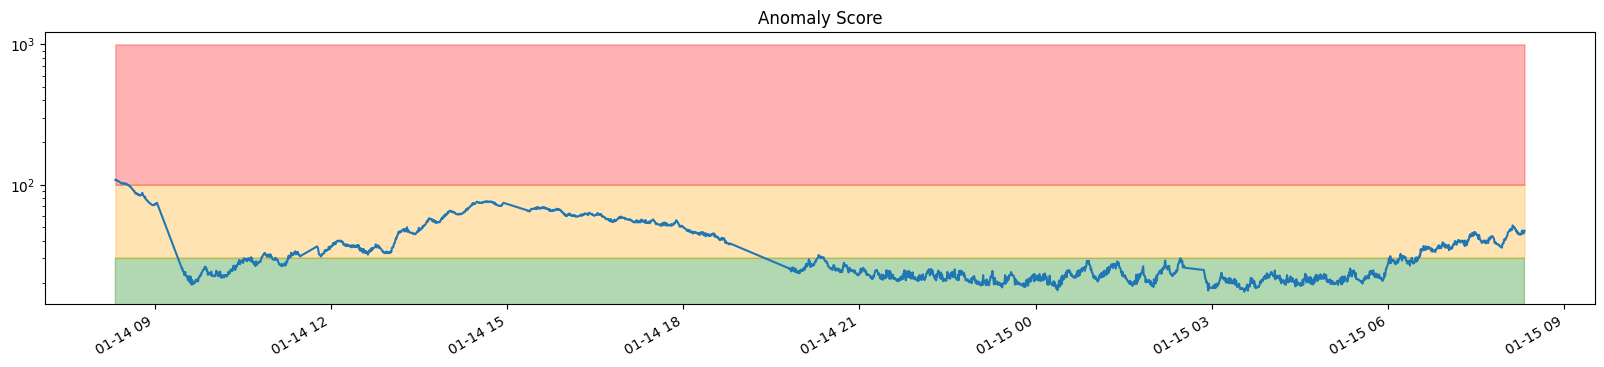

In [20]:
# normalize the data
X = scaler.transform(df)
# reshape inputs for LSTM [samples, timesteps, features]
X = X.reshape(X.shape[0], 1, X.shape[1])
print("Training data shape:", X.shape)

X_pred = model.predict(X)
X_pred = X_pred .reshape(X_pred .shape[0], X_pred .shape[2])
X_pred = pd.DataFrame(X_pred , columns=df.columns)
X_pred_original = scaler.inverse_transform(X_pred) #Se guarda la prediccion en otro DS
X_pred.index = df.index
scored = pd.DataFrame(index=df.index)
X_reshaped = X.reshape(X.shape[0], X.shape[2])
scored['Loss_mae'] = np.mean(np.abs(X_pred - X_reshaped), axis=1)
scored['Threshold'] = threshold


#concatenar scored_train y scored_test
scored.columns=['Factor de Anomalia Molino', 'Umbral Anomalia Molino']
scored['Factor de Anomalia Molino'] = 100*scored['Factor de Anomalia Molino'] / scored['Umbral Anomalia Molino']
scored['Factor de Anomalia Molino'] = scored['Factor de Anomalia Molino'].clip(upper=110)
scored['Umbral Anomalia Molino'] = 100



scored['Factor de Anomalia Molino'] = 0.2*scored['Factor de Anomalia Molino'] + anomaly_scores['total_score']
scored['Anomalia Molino'] = scored['Factor de Anomalia Molino'] > scored['Umbral Anomalia Molino']
scored['Factor de Anomalia Molino'] = scored['Factor de Anomalia Molino'].clip(upper=1000)
scored['Anomalia Molino'] = scored['Anomalia Molino'].astype(int)

# Crear la figura y el eje
fig, ax = plt.subplots(figsize=(20, 4))

# Graficar los datos

scored['Factor de Anomalia Molino'].plot(ax=ax, title='Anomaly Score') #.iloc[25000:25500]

# Cambiar la escala del eje y a logarítmica
ax.set_yscale('log')

# Agregar 'mean_plus_2std' y 'mean_minus_2std' como una banda sombreada entre mean_plus_2std y mean_minus_2std
plt.fill_between(scored.index, 0, 30, color='green', alpha=0.3)
plt.fill_between(scored.index, 30, 100, color='orange', alpha=0.3)
plt.fill_between(scored.index, 100, 1000, color='red', alpha=0.3)

# Mostrar el g
plt.show()

In [21]:
scored.to_csv('result.csv')

In [22]:
X_pred

,UH/I,UH/PT,masa/TT_MasaCanLL,masa/TT_MasaCanLM,masa/TT_MasaSupLL,masa/TT_MasaSupLM,motor/I,motor/ST,motor/TT_DE,motor/TT_NDE,motor/TT_R,motor/TT_S,motor/TT_T,motor/VT_DE,motor/VT_MotorNDE,reductor/VT_I,reductor/VT_rII
2025-01-14 08:19:55.224353300-05:00,0.409753,0.501501,0.253407,0.233041,0.252973,0.289054,0.616243,0.630423,0.614966,0.521858,0.700514,0.702049,0.702951,0.255016,0.232448,0.289784,0.247183
2025-01-14 08:20:25.224353300-05:00,0.389025,0.484204,0.262223,0.230760,0.273486,0.302275,0.623979,0.682500,0.631470,0.496176,0.697010,0.699770,0.699047,0.323725,0.295132,0.364534,0.283834
2025-01-14 08:20:55.224353300-05:00,0.410591,0.496738,0.253872,0.232722,0.254009,0.289767,0.614926,0.612924,0.616948,0.515816,0.699814,0.701253,0.702229,0.246365,0.226426,0.281913,0.238109
2025-01-14 08:21:25.224353300-05:00,0.420174,0.505593,0.250727,0.234292,0.245800,0.284276,0.609925,0.594490,0.611870,0.528522,0.701620,0.702381,0.704061,0.220438,0.202760,0.252871,0.224979
2025-01-14 08:21:55.224353300-05:00,0.403683,0.496124,0.255718,0.232207,0.258602,0.292751,0.618832,0.643909,0.619000,0.513962,0.699332,0.701272,0.701700,0.273353,0.249197,0.310014,0.256723
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-15 08:17:25.224353300-05:00,0.383175,0.480065,0.256471,0.218113,0.273413,0.301197,0.611179,0.710119,0.602410,0.452994,0.658780,0.663541,0.661731,0.361230,0.327729,0.401873,0.304556
2025-01-15 08:17:55.224353300-05:00,0.389050,0.477239,0.253167,0.217550,0.266769,0.297222,0.609753,0.660224,0.597264,0.449448,0.658692,0.663115,0.661980,0.319655,0.292765,0.360336,0.274701
2025-01-15 08:18:25.224353300-05:00,0.386042,0.476459,0.254767,0.217781,0.269907,0.299241,0.610923,0.675100,0.600386,0.448735,0.659065,0.663636,0.662230,0.333592,0.304922,0.374925,0.283843
2025-01-15 08:18:55.224353300-05:00,0.380526,0.475048,0.258139,0.218127,0.276709,0.303437,0.612399,0.705981,0.607025,0.447119,0.659362,0.664157,0.662226,0.363785,0.331317,0.405980,0.303331


In [23]:
X_pred_df = pd.DataFrame(X_pred_original, columns=df.columns,index=df.index)
X_pred_df

,UH/I,UH/PT,masa/TT_MasaCanLL,masa/TT_MasaCanLM,masa/TT_MasaSupLL,masa/TT_MasaSupLM,motor/I,motor/ST,motor/TT_DE,motor/TT_NDE,motor/TT_R,motor/TT_S,motor/TT_T,motor/VT_DE,motor/VT_MotorNDE,reductor/VT_I,reductor/VT_rII
2025-01-14 08:19:55.224353300-05:00,4.114630,1.631425,40.272591,41.672794,39.092407,43.124321,707.603638,861.897644,51.966770,50.522381,87.121178,86.525002,89.829666,0.813239,0.869091,3.597127,3.707745
2025-01-14 08:20:25.224353300-05:00,4.083537,1.592400,40.977802,41.499325,40.618290,44.182022,712.720093,908.313538,52.788017,49.164608,86.818344,86.318619,89.474167,1.021060,1.091082,4.525008,4.257506
2025-01-14 08:20:55.224353300-05:00,4.115887,1.620679,40.309799,41.648525,39.169445,43.181339,706.732666,846.300476,52.065384,50.202965,87.060738,86.452934,89.763863,0.787073,0.847767,3.499426,3.571628
2025-01-14 08:21:25.224353300-05:00,4.130262,1.640656,40.058155,41.767914,38.558838,42.742111,703.424622,829.870483,51.812698,50.874664,87.216812,86.555069,89.930649,0.708651,0.763953,3.138927,3.374679
2025-01-14 08:21:55.224353300-05:00,4.105524,1.619293,40.457439,41.609367,39.511078,43.420048,709.316345,873.917358,52.167492,50.104958,87.018990,86.454643,89.715759,0.868702,0.928409,3.848249,3.850843
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-15 08:17:25.224353300-05:00,4.074762,1.583063,40.517651,40.537498,40.612854,44.095734,704.253723,932.930786,51.341942,46.881687,83.513718,83.037773,86.076790,1.134500,1.206522,4.988501,4.568336
2025-01-15 08:17:55.224353300-05:00,4.083575,1.576688,40.253334,40.494705,40.118652,43.777729,703.310608,888.458862,51.085876,46.694225,83.506096,82.999123,86.099464,1.008752,1.082701,4.472905,4.120517
2025-01-15 08:18:25.224353300-05:00,4.079063,1.574927,40.381363,40.512241,40.352016,43.939308,704.085022,901.717896,51.241241,46.656551,83.538330,83.046364,86.122208,1.050905,1.125753,4.653997,4.257649
2025-01-15 08:18:55.224353300-05:00,4.070789,1.571744,40.651138,40.538582,40.857971,44.274971,705.061096,929.242371,51.571575,46.571110,83.564041,83.093513,86.121902,1.142230,1.219229,5.039482,4.549967


In [24]:
anomaly_pred_1 = calculate_anomaly_score_1(X_pred_df,df_umbrales,importancia=0.3)
anomaly_pred_2 = calculate_anomaly_score_2(X_pred_df,df_umbrales,importancia=0.7,b=0.01,a=2)
anommaly_pred = anomaly_pred_1 + anomaly_pred_2

df_input = pd.merge(anomaly_scores, scored, left_index=True, right_index=True)
df_input
df_anomaly = df_input[df_input['Anomalia Molino']==1]
df_anomaly

,UH/I,UH/PT,masa/TT_MasaCanLL,masa/TT_MasaCanLM,masa/TT_MasaSupLL,masa/TT_MasaSupLM,motor/I,motor/ST,motor/TT_DE,motor/TT_NDE,...,motor/TT_S,motor/TT_T,motor/VT_DE,motor/VT_MotorNDE,reductor/VT_I,reductor/VT_rII,total_score,Factor de Anomalia Molino,Umbral Anomalia Molino,Anomalia Molino
2025-01-14 08:19:55.224353300-05:00,23.300188,10.094475,111.715355,30.020781,4.509219,0.0,5.050451,3.949942,0.482753,22.916750,...,15.675960,10.811945,10.961786,13.371960,0.750767,9.589162,94.333704,107.998382,100,1
2025-01-14 08:20:25.224353300-05:00,23.284750,10.067013,111.524007,30.020584,4.522950,0.0,5.751145,7.653437,0.453103,22.919916,...,15.644578,10.782146,6.577868,8.624448,4.653736,4.597841,93.770873,108.764038,100,1
2025-01-14 08:20:55.224353300-05:00,23.186978,10.089183,111.194067,30.020499,4.493366,0.0,5.114072,4.973200,0.454757,22.911474,...,15.633690,10.761164,10.311098,12.588263,2.469590,14.847266,94.208662,108.040901,100,1
2025-01-14 08:21:25.224353300-05:00,23.261593,9.998128,111.005019,30.020457,4.443415,0.0,5.937616,2.823849,0.442172,22.905096,...,15.620672,10.745974,8.777231,12.534646,6.283956,16.073676,94.144260,107.365390,100,1
2025-01-14 08:21:55.224353300-05:00,23.324887,9.991160,110.866577,30.020431,4.413444,0.0,5.745728,3.774541,0.410371,22.891598,...,15.594867,10.725053,10.967545,10.743137,1.920971,8.232446,93.309948,107.238693,100,1
2025-01-14 08:22:25.224353300-05:00,23.320771,9.982202,110.495923,30.020518,4.393464,0.0,6.323539,3.527685,0.381580,22.882335,...,15.569647,10.705581,5.359361,9.329387,0.559393,10.501688,92.569396,105.744540,100,1
2025-01-14 08:22:55.224353300-05:00,23.238437,9.972843,110.010898,30.021006,4.407006,0.0,6.193043,3.592457,0.345686,22.875266,...,15.539454,10.681467,9.767445,11.249749,0.110451,11.846483,92.519892,106.093945,100,1
2025-01-14 08:23:25.224353300-05:00,23.298258,9.967441,109.524232,30.021377,4.424263,0.0,6.195696,3.282775,0.316465,22.869173,...,15.512150,10.656036,11.764542,13.279777,2.743592,13.551015,92.534734,106.015008,100,1
2025-01-14 08:23:55.224353300-05:00,23.308764,9.962504,108.922293,30.021914,4.437686,0.0,6.115674,3.670956,0.285346,22.859606,...,15.489221,10.634229,9.701198,9.603530,1.432247,9.767347,91.269791,105.011381,100,1
2025-01-14 08:24:25.224353300-05:00,23.270856,9.960945,108.295698,30.022504,4.448423,0.0,5.971929,4.182312,0.261162,22.850441,...,15.467149,10.614390,9.583676,10.222606,2.753889,7.891908,90.655422,104.599134,100,1


In [25]:
df_anomaly.to_csv('desfases.csv')

In [26]:
scored.tail(3)

,Factor de Anomalia Molino,Umbral Anomalia Molino,Anomalia Molino
2025-01-15 08:18:25.224353300-05:00,45.721424,100,0
2025-01-15 08:18:55.224353300-05:00,45.095498,100,0
2025-01-15 08:19:25.224353300-05:00,47.017088,100,0


In [27]:
scored.columns = ['Resultados.Molino.Factor_anomalia',
                 'Resultados.Molino.Umbral Anomalia',
                 'Resultados.Molino.anomaly']

In [28]:
import pandas as pd
import arrow

# Asegúrate de que la columna con marcas de tiempo esté en formato Arrow
# Si el índice está en formato Arrow, puedes hacer lo siguiente:
if isinstance(scored.index[0], arrow.arrow.Arrow):
    # Convertir a formato datetime
    scored.index = pd.to_datetime([ts.datetime for ts in scored.index])

# Si la columna 'timestamp' está en formato Arrow, puedes hacer lo mismo
if 'timestamp' in scored.columns and isinstance(scored['timestamp'][0], arrow.arrow.Arrow):
    scored['timestamp'] = pd.to_datetime([ts.datetime for ts in scored['timestamp']])

# Continuar con el resto del código
scored.reset_index(inplace=True)
scored.rename(columns={'index': 'timestamp'}, inplace=True)
scored['timestamp'] = scored['timestamp'].dt.strftime('%m/%d/%Y %H:%M:%S')

# Exportar a CSV
# scored.to_csv('deployment_molino.csv', index=False)
scored.to_csv('//PEAAAUCOI211/CSV Import/Resultados/deployment_molino.csv', index=False)


### 7. CALCULO DE IMPORTANCIAS

In [29]:
df_desfase = anomaly_scores.copy()
df_desfase.drop(columns=['total_score'], inplace=True)
#Agregar a las columnas de df_desfase el '_desfase' al final de cada nombre
df_desfase.columns = ['Resultados.Molino.Desfases.'+column + '_desfase' for column in df_desfase.columns]


In [30]:
import arrow

# # Convierte el índice a datetime nativo de pandas
# df_desfase.index = [arrow_date.datetime for arrow_date in df_desfase.index]

# # Asegura que el índice sea de tipo datetime en pandas
# df_desfase.index = pd.to_datetime(df_desfase.index)
# df_desfase.index.name = 'timestamp'

In [31]:

df_desfase.reset_index(inplace=True)
df_desfase.rename(columns={'index': 'timestamp'}, inplace=True)
df_desfase['timestamp'] = df_desfase['timestamp'].dt.strftime('%m/%d/%Y %H:%M:%S')
#df.set_index('Fecha y Hora', inplace=True)

In [32]:
# df_desfase.to_csv('desfases_molino.csv',index=False)
df_desfase.to_csv('//PEAAAUCOI211/CSV Import/Resultados/desfases_molino.csv',index=False)

In [33]:
# # Iterar sobre cada columna en anomaly_scores


# for column in anomaly_scores.columns:
#     # Crear la figura y el eje
#     fig, ax = plt.subplots(figsize=(20, 4))

#     # Graficar los datos
#     anomaly_scores[column].plot(ax=ax, title=f'Anomaly Score: {column}')

#     # Cambiar la escala del eje y a logarítmica
#     #ax.set_yscale('log')

#     # Agregar 'mean_plus_2std' y 'mean_minus_2std' como una banda sombreada entre mean_plus_2std y mean_minus_2std
#     plt.fill_between(anomaly_scores.index, 0, 30, color='green', alpha=0.3)
#     plt.fill_between(anomaly_scores.index, 30, 100, color='red', alpha=0.3)

#     # Mostrar el gráfico
#     plt.show()

### 8. PROGRAMACIÓN DE AUTOEJECUCIÓN DE SCRIPT

In [34]:
#spy.jobs.schedule('every 5 minutes')
#spy.jobs.unschedule()